## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as datetime

from scipy import stats
from pyhive import presto
from datetime import datetime, timedelta

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 300)

In [3]:
## Connection
connection = presto.connect(
        host='presto-gateway.serving.data.production.internal',
        port=80,
        protocol='http',
        catalog='hive',
        username='jerin.steefan@rapido.bike'
)

## Parameter

In [4]:
## Parameter 
start_date = '20231106'
end_date = '20231117'

start_date_range = datetime.strptime(start_date, '%Y%m%d')
end_date_range = datetime.strptime(end_date, '%Y%m%d')

In [5]:
print(os.getcwd())

data_path = '/Users/rapido/local-datasets/customer/Ads-Monetisation/home-screen-analysis/m0vsm2/'
print(data_path)

/Users/rapido/analytics/customer/Ads-Monetisation/home-screen-analysis 
/Users/rapido/local-datasets/customer/Ads-Monetisation/home-screen-analysis/m0vsm2/


## Datasets

### AO/SA/FE/RR

In [6]:
df_data_dump = pd.DataFrame()

current_date = start_date_range
while current_date <= end_date_range:
    
    current_date_str = current_date.strftime('%Y%m%d')

    query = f"""
        WITH ao AS (
    
        SELECT
            DISTINCT
            yyyymmdd,
            quarter_hour,
            CAST(SUBSTR(quarter_hour,1,2) AS INT) hour,
            JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.userId') userId,
            JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.userId') appOpen_userId,
            JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.currentCity') currentCity,
            JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.screen_version') screen_version,
            CAST(CAST(JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.CTSessionId') AS DECIMAL) AS VARCHAR) CTSessionId

        FROM 
            raw.clevertap_customer_events_master
        WHERE 
            yyyymmdd = '{current_date_str}'
            AND profile_platform = 'Android'
            AND eventname = 'orderactivity'
            AND JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.currentCity') IN ('Hyderabad', 'Delhi', 'Kolkata', 'Bangalore')
            AND JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.screen_version') IN ('M0', 'M2')
            AND JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.order_activity_source') = 'appOpen' 
        ),

        sa AS (

        SELECT 
            DISTINCT
            yyyymmdd,
            CAST(SUBSTR(quarter_hour,1,2) AS INT) hour,
            JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.userId') userId,
            JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.userId') searchaddress_userId,
            JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.currentCity') currentCity,
            JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.screen_version') screen_version,
            CAST(CAST(JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.CTSessionId') AS DECIMAL) AS VARCHAR) CTSessionId 
        FROM 
            raw.clevertap_customer_events_master sa

        WHERE 
            yyyymmdd = '{current_date_str}'
            AND eventname = 'searchaddress'
            AND JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.currentCity') IN ('Hyderabad', 'Delhi', 'Kolkata', 'Bangalore')
            AND JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.screen_version') IN ('M0', 'M2')    
        ),

        fe AS (

        SELECT 
            fe.yyyymmdd,
            fe.user_id fe_userId,
            fe.city,
            fe.fare_estimate_id,
            -- service_name,
            fe.service_detail_id,
            sfe.session_id,
            CAST(SUBSTR(fe.quarter_hour,1,2) AS INT) hour
        FROM 
            pricing.fare_estimates_enriched fe

        JOIN sa
            ON sa.yyyymmdd = fe.yyyymmdd 
            AND sa.userId = fe.user_id
            AND sa.hour = CAST(SUBSTR(fe.quarter_hour,1,2) AS INT)

        LEFT JOIN hive.marketplace.session_fare_estimates sfe    
            ON sfe.yyyymmdd = fe.yyyymmdd
            AND sfe.fare_estimate_id = fe.fare_estimate_id

        WHERE 
            fe.yyyymmdd = '{current_date_str}'
            AND fe.city IN ('Hyderabad', 'Delhi', 'Kolkata', 'Bangalore')

        GROUP BY 1,2,3,4,5,6,7
        ),

        rr AS (

        SELECT
            orderdate,
            city,
            service_name,
            service_detail_id,
            customer_id,
            u.id_array as fare_estimate_id,
            order_id,
            order_status,
            spd_fraud_flag
        FROM
            (
            SELECT   
                date_format(from_unixtime(epoch / 1000, 'Asia/Kolkata'), '%Y%m%d') AS orderdate,
                city_name as city,
                service_obj_service_name as service_name,
                service_detail_id,
                customer_id,
                order_id,
                order_status,
                spd_fraud_flag,
                estimate_id,
                estimate_ids,
                cast(json_parse(estimate_ids) as array<varchar>) AS id_array
            FROM
                orders.order_logs_snapshot

            WHERE
                yyyymmdd = '{current_date_str}'
                AND city_name IN ('Hyderabad', 'Delhi', 'Kolkata', 'Bangalore')
            ) as t
        CROSS JOIN UNNEST(t.id_array) AS u(id_array)

        JOIN 
            sa
            ON sa.userId = t.customer_id
        )

        SELECT 
            ao.yyyymmdd,
            ao.quarter_hour,
            ao.currentCity,
            ao.screen_version,
            ao.appOpen_userId,
            sa.searchaddress_userId,
            sa.hour,
            fe.fe_userId,
            fe.session_id,
            fe.fare_estimate_id,
            rr.customer_id rr_userId,
            rr.order_id,
            rr.order_status,
            rr.spd_fraud_flag

        FROM 
            ao

        LEFT JOIN
            sa
            ON ao.yyyymmdd = sa.yyyymmdd
            AND ao.userId = sa.userId
            AND ao.CTSessionId = sa.CTSessionId

        LEFT JOIN 
            fe
            ON sa.yyyymmdd = fe.yyyymmdd
            AND sa.userId = fe.fe_userId
            AND sa.hour = fe.hour

        LEFT JOIN 
            rr
            ON fe.yyyymmdd = rr.orderdate
            AND fe.fare_estimate_id = rr.fare_estimate_id
            AND fe.service_detail_id = rr.service_detail_id 

    """
    
    # Execute the query and append the results to the DataFrame
    print('Reading ->', current_date_str)
    day_data = pd.read_sql(query, connection)
    df_data_dump = pd.concat([df_data_dump, day_data], ignore_index=True)

    # Move to the next day
    current_date += timedelta(days=1)

df_data_dump.to_csv(data_path + 
                    'df_data_dump_{}_{}.csv'.format(start_date,end_date),
                    index=False)

Reading -> 20231106
Reading -> 20231107
Reading -> 20231108
Reading -> 20231109
Reading -> 20231110
Reading -> 20231111
Reading -> 20231112
Reading -> 20231113
Reading -> 20231114
Reading -> 20231115
Reading -> 20231116
Reading -> 20231117


In [7]:
## read local extract
df_data_dump = pd.read_csv(data_path + 
                           'df_data_dump_{}_{}.csv' \
                           .format(start_date,end_date)
                          )
df_data_dump.head(2)

,yyyymmdd,quarter_hour,currentCity,screen_version,appOpen_userId,searchaddress_userId,hour,fe_userId,session_id,fare_estimate_id,rr_userId,order_id,order_status,spd_fraud_flag
0,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN
1,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN


In [8]:
df_data_dump.screen_version.describe()

count     7111467
unique          2
top            M0
freq      6100219
Name: screen_version, dtype: object

In [43]:
df_data_dump.groupby(['yyyymmdd','screen_version']).agg({'appOpen_userId' : 'nunique'})

appOpen_userId
yyyymmdd screen_version                
20231106 M0                       22729
         M2                          10
20231107 M0                       23145
         M2                           7
20231108 M0                       23214
         M2                          22
20231109 M0                       23002
         M2                          74
20231110 M0                       23941
         M2                          86
20231111 M0                       20262
         M2                         118
20231112 M0                       14818
         M2                         143
20231113 M0                       17611
         M2                         312
20231114 M0                       19849
         M2                         549
20231115 M0                       24415
         M2                        2838
20231116 M0                       37205
         M2                       11290
20231117 M0                       47422
         M2                       34445

### iAllocator Segments

In [9]:
##iallocator_customer_segments

iallocator_customer_segments = f"""

    SELECT 
        customer_id,
        taxi_recency_segment recency_segment,
        taxi_service_affinity service_affinity,
        COALESCE(taxi_rr_recency_last_90_days, 99) rr_recency_last_90_days
    FROM 
        datasets.iallocator_customer_segments
    WHERE 
        run_date = DATE_FORMAT(DATE_PARSE('{start_date}', '%Y%m%d'), '%Y-%m-%d')
        AND taxi_recency_segment != 'INACTIVE'
        AND taxi_lifetime_rides > 1
        -- AND taxi_lifetime_last_ride_city IN ('Hyderabad', 'Delhi', 'Kolkata', 'Bangalore')
"""

df_iallocator_customer_segments = pd.read_sql(iallocator_customer_segments, connection)
df_iallocator_customer_segments \
                            .to_csv(data_path + 
                                    'iallocator_customer_segments_{}.csv' \
                            .format(start_date), index=False)

In [10]:
## read local extract
df_iallocator_customer_segments = pd.read_csv(data_path + 
                                              'iallocator_customer_segments_{}.csv' \
                                              .format(start_date)
                                             )

In [11]:
print(df_iallocator_customer_segments.shape)
df_iallocator_customer_segments.head(3)

(13561486, 4)


,customer_id,recency_segment,service_affinity,rr_recency_last_90_days
0,61584c01c94e79d9efcd2651,DORMANT,ONLY_AUTO,36
1,63b55a9bba808ba75c3f5d3b,RECENT,ONLY_LINK,1
2,61372210a0fbe0e5671fdec0,STATIONARY,ONLY_AUTO,8


In [12]:
print(df_data_dump.columns)
print(df_iallocator_customer_segments.columns)

Index(['yyyymmdd', 'quarter_hour', 'currentCity', 'screen_version',
       'appOpen_userId', 'searchaddress_userId', 'hour', 'fe_userId',
       'session_id', 'fare_estimate_id', 'rr_userId', 'order_id',
       'order_status', 'spd_fraud_flag'],
      dtype='object')
Index(['customer_id', 'recency_segment', 'service_affinity',
       'rr_recency_last_90_days'],
      dtype='object')


In [13]:
df_segment_merge = pd.merge(df_data_dump,
                    df_iallocator_customer_segments,
                    how='left',
                    left_on=['appOpen_userId'],
                    right_on=['customer_id']
                  )
df_segment_merge['recency_segment'].fillna('UNKNOWN', inplace=True)
df_segment_merge['service_affinity'].fillna('UNKNOWN', inplace=True)
df_segment_merge.head(2)

,yyyymmdd,quarter_hour,currentCity,screen_version,appOpen_userId,searchaddress_userId,hour,fe_userId,session_id,fare_estimate_id,rr_userId,order_id,order_status,spd_fraud_flag,customer_id,recency_segment,service_affinity,rr_recency_last_90_days
0,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN,641e82ffc541dad86f187399,RECENT,ONLY_LINK,0.0
1,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN,641e82ffc541dad86f187399,RECENT,ONLY_LINK,0.0


### Checking

In [14]:
df_segment_merge.service_affinity.unique()

array(['ONLY_LINK', 'ONLY_AUTO', 'BOTH', 'UNKNOWN'], dtype=object)

In [15]:
df_segment_merge.recency_segment.unique()

array(['RECENT', 'DORMANT', 'UNKNOWN', 'STATIONARY'], dtype=object)

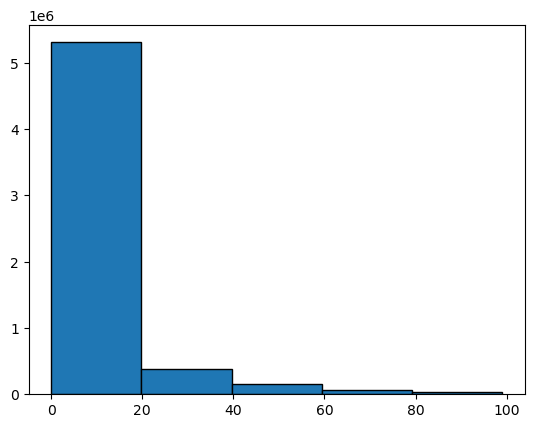

In [16]:
plt.hist(df_segment_merge['rr_recency_last_90_days'], bins=5, edgecolor='black'); plt.show()

In [17]:
df_segment_merge['rr_recency'] = np.where(df_segment_merge['rr_recency_last_90_days'] <= 21, '1. Active in last 21 days',
                                 np.where(df_segment_merge['rr_recency_last_90_days'] <= 64, '2. Active in  to last 22 to 64 days',
                                 np.where(df_segment_merge['rr_recency_last_90_days'] <= 90.0, '3. Active in  to last 65 to 90 days', 
                                 '4. Not active in last 90 days')))

In [18]:
## Refined df
df_refined = df_segment_merge
df_refined.head(2)

,yyyymmdd,quarter_hour,currentCity,screen_version,appOpen_userId,searchaddress_userId,hour,fe_userId,session_id,fare_estimate_id,rr_userId,order_id,order_status,spd_fraud_flag,customer_id,recency_segment,service_affinity,rr_recency_last_90_days,rr_recency
0,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN,641e82ffc541dad86f187399,RECENT,ONLY_LINK,0.0,1. Active in last 21 days
1,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN,641e82ffc541dad86f187399,RECENT,ONLY_LINK,0.0,1. Active in last 21 days


## Sampling bias

- Objective here is to double validate is there any samping bias between test/control group.
- Check behaviour of customer between M0 vs. M0.5
- Check can be done in terms of distribution of customers segment, fe, rr, net orders and others


<b>Procedure</b> <br>
Take tc group customer and see the desired distributions on pre-period 

In [19]:
## Pre-period Parameter

## Month of OCT
start_date = start_date
end_date = start_date

## Month of SEP (2 weeks)
pre_start_date = '20230904'
pre_end_date = '20230917'

In [20]:
##sampling_bias

sampling_bias = f"""

    WITH orderactivity_customer AS (
    
    SELECT 
        JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.userId') userId,
        JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.screen_version') screen_version
    FROM 
        raw.clevertap_customer_events_master
    WHERE 
        yyyymmdd >= '{start_date}'
        AND yyyymmdd <= '{end_date}'
        AND profile_platform = 'Android'
        AND eventname = 'orderactivity'
        AND JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.order_activity_source') = 'appOpen' 
        AND JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.currentCity') IN ('Hyderabad', 'Delhi', 'Kolkata', 'Bangalore')
        AND JSON_EXTRACT_SCALAR(eventProps, '$.eventProps.screen_version') IN ('M0', 'M2')
    GROUP BY 1,2
    ),
    
    fare_estimates_enriched AS (
    
    SELECT 
        fe.yyyymmdd,
        ao.screen_version,
        fe.user_id fe_userId,
        fe.city,
        fe.fare_estimate_id,
        -- service_name,
        fe.service_detail_id,
        sfe.session_id
    FROM 
        pricing.fare_estimates_enriched fe
        
    JOIN
        orderactivity_customer ao
        ON ao.userId = fe.user_id
        
    LEFT JOIN hive.marketplace.session_fare_estimates sfe    
        ON sfe.yyyymmdd = fe.yyyymmdd
        AND sfe.fare_estimate_id = fe.fare_estimate_id
        
    WHERE 
        fe.yyyymmdd >= '{pre_start_date}'
        AND fe.yyyymmdd <= '{pre_end_date}'
        AND fe.city IN ('Hyderabad', 'Delhi', 'Kolkata', 'Bangalore')

    GROUP BY 1,2,3,4,5,6,7
    ),
    
    order_logs_snapshot AS (
    
    SELECT
        orderdate,
        city,
        service_name,
        service_detail_id,
        customer_id,
        u.id_array as fare_estimate_id,
        order_id,
        order_status,
        spd_fraud_flag
    FROM
        (
        SELECT   
            date_format(from_unixtime(epoch / 1000, 'Asia/Kolkata'), '%Y%m%d') AS orderdate,
            city_name as city,
            service_obj_service_name as service_name,
            service_detail_id,
            customer_id,
            order_id,
            order_status,
            spd_fraud_flag,
            estimate_id,
            estimate_ids,
            cast(json_parse(estimate_ids) as array<varchar>) AS id_array
        FROM
            orders.order_logs_snapshot

        WHERE
            yyyymmdd >= '{pre_start_date}'
            AND yyyymmdd <= '{pre_end_date}'
            AND city_name IN ('Hyderabad', 'Delhi', 'Kolkata', 'Bangalore')
        ) as t
    CROSS JOIN UNNEST(t.id_array) AS u(id_array)
    
    JOIN 
        orderactivity_customer ao
        ON ao.userId = t.customer_id
    )
    
    SELECT 
        fe.*,
        rr.customer_id rr_customer,
        rr.fare_estimate_id rr_fare_estimate_id,
        rr.service_name rr_service_name,
        rr.order_id,
        rr.order_status,
        rr.spd_fraud_flag,
        COALESCE(taxi_recency_segment, 'NA') recency_segment,
        COALESCE(taxi_lifetime_stage, 'NA') lifetime_stage,
        COALESCE(taxi_service_affinity, 'NA') service_affinity
        
    FROM 
        fare_estimates_enriched fe
    
    LEFT JOIN 
        order_logs_snapshot rr
        ON fe.yyyymmdd = rr.orderdate
        AND fe.fare_estimate_id = rr.fare_estimate_id
        AND fe.service_detail_id = rr.service_detail_id
    
    LEFT JOIN 
        datasets.iallocator_customer_segments cs
        ON fe.fe_userId = cs.customer_id
        AND run_date = '2023-09-17'
        AND taxi_recency_segment != 'INACTIVE'
        AND taxi_lifetime_rides > 1 
        
"""

df_sampling_bias = pd.read_sql(sampling_bias, connection)
df_sampling_bias \
            .to_csv(data_path +
                    'sampling_bias_{}_{}_{}_{}.csv' \
            .format(start_date,end_date,pre_start_date,pre_end_date), index=False)

In [21]:
## read local extract
df_sampling_bias = pd.read_csv(data_path + 
                               'sampling_bias_{}_{}_{}_{}.csv' \
                               .format(start_date,end_date,pre_start_date,pre_end_date)
                              )

print(df_sampling_bias.shape)
df_sampling_bias.head(2)

(1637478, 16)


,yyyymmdd,screen_version,fe_userId,city,fare_estimate_id,service_detail_id,session_id,rr_customer,rr_fare_estimate_id,rr_service_name,order_id,order_status,spd_fraud_flag,recency_segment,lifetime_stage,service_affinity
0,20230916,M0,5cb6d7db54bc7263ff3df3c3,Hyderabad,6505de4cf1dd261aaa1d57ae,5e993fee271f4612f176f2d2,5f9aaedf-f524-4837-bffc-dfb44da5afe6,NaN,NaN,NaN,NaN,NaN,NaN,RECENT,COMMITTED,BOTH
1,20230907,M0,5e10ad1ea10a71228f8de5f2,Hyderabad,64f97876b3c52945b5caac82,64c2487410ce802ee2adf393,66da4537-4a9e-4318-95bf-99ca40bdacc3,NaN,NaN,NaN,NaN,NaN,NaN,RECENT,DETOX,ONLY_LINK


In [22]:
sampling_bias_backup = df_sampling_bias

### Funnel metrics

In [23]:
df_bias1 = sampling_bias_backup \
                    .groupby(['city', 'screen_version']) \
                    .agg(fe_customers = pd.NamedAgg('fe_userId' , 'nunique'),
                         rr_customers = pd.NamedAgg('rr_customer' , 'nunique'),
                         net_customers = ('rr_customer', 
                                          lambda x: x[(sampling_bias_backup['order_status'] == 'dropped') 
                                                      &
                                                      (sampling_bias_backup['spd_fraud_flag'] != True)
                                                     ] \
                                          .nunique()),
                         #fe_count = pd.NamedAgg('fare_estimate_id' , 'nunique'),
                         #rr_count = pd.NamedAgg('order_id' , 'nunique'),
                         fe_count = pd.NamedAgg('session_id' , 'nunique'),
                         rr_count = ('session_id', 
                                      lambda x: x[(sampling_bias_backup['rr_fare_estimate_id'].notna())
                                                  &
                                                  (sampling_bias_backup['rr_fare_estimate_id'] != '')
                                                 ] \
                                      .nunique()),
                         
                         net_count = ('session_id', 
                                      lambda x: x[(sampling_bias_backup['order_status'] == 'dropped')
                                                  &
                                                  (sampling_bias_backup['spd_fraud_flag'] != True)
                                                 ] \
                                      .nunique())
                        ) \
                    .reset_index()

## Adding new columns

df_bias1['FE2RR-User'] = df_bias1['rr_customers']*100.0/df_bias1['fe_customers']
df_bias1['G2N-User'] = df_bias1['net_customers']*100.0/df_bias1['rr_customers']
df_bias1['FE2NET-User'] = df_bias1['net_customers']*100.0/df_bias1['fe_customers']

df_bias1['FE2RR'] = df_bias1['rr_count']*100.0/df_bias1['fe_count']
df_bias1['G2N'] = df_bias1['net_count']*100.0/df_bias1['rr_count']
df_bias1['FE2NET'] = df_bias1['net_count']*100.0/df_bias1['fe_count']

print('\n\nHome M0 vs. M0.5 test/control pre-period funnel metric comparision\nSep-04 to Sep-17')
df_bias1.round(2)



Home M0 vs. M0.5 test/control pre-period funnel metric comparision
Sep-04 to Sep-17


,city,screen_version,fe_customers,rr_customers,net_customers,fe_count,rr_count,net_count,FE2RR-User,G2N-User,FE2NET-User,FE2RR,G2N,FE2NET
0,Bangalore,M0,3377,3097,2729,31382,24111,15268,91.71,88.12,80.81,76.83,63.32,48.65
1,Bangalore,M2,10,8,5,83,46,26,80.00,62.50,50.00,55.42,56.52,31.33
2,Delhi,M0,4240,3849,3614,44030,32884,26598,90.78,93.89,85.24,74.69,80.88,60.41
3,Hyderabad,M0,7798,7056,6322,64785,47678,32428,90.48,89.60,81.07,73.59,68.01,50.05
4,Hyderabad,M2,3,0,0,7,0,0,0.00,NaN,0.00,0.00,NaN,0.00
5,Kolkata,M0,778,659,583,6155,4439,3141,84.70,88.47,74.94,72.12,70.76,51.03
6,Kolkata,M2,1,1,0,1,1,0,100.00,0.00,0.00,100.00,0.00,0.00


<b>Take-----UPDATE</b> 

- Session level metrics 
    
    FE2RR/FE2NET -> Similary behaviour on M0 vs M0.5 (slight difference in Kolkata )
    
    
- Customer level metrics
    
    FE2RR User/FE2NET User -> Consistence ~2 % delta between M0 vs M0.5

<br>

### recency_segment

In [24]:
df_bias2 = sampling_bias_backup \
                    .groupby(['city', 'screen_version', 'recency_segment']) \
                    .agg(fe_customers = pd.NamedAgg('fe_userId' , 'nunique'),
                         rr_customers = pd.NamedAgg('rr_customer' , 'nunique'),
                         net_customers = ('rr_customer', 
                                          lambda x: x[(sampling_bias_backup['order_status'] == 'dropped') 
                                                      &
                                                      (sampling_bias_backup['spd_fraud_flag'] != True)
                                                     ] \
                                          .nunique()),
                         #fe_count = pd.NamedAgg('fare_estimate_id' , 'nunique'),
                         #rr_count = pd.NamedAgg('order_id' , 'nunique'),
                         fe_count = pd.NamedAgg('session_id' , 'nunique'),
                         rr_count = ('session_id', 
                                      lambda x: x[(sampling_bias_backup['rr_fare_estimate_id'].notna())
                                                  &
                                                  (sampling_bias_backup['rr_fare_estimate_id'] != '')
                                                 ] \
                                      .nunique()),
                         
                         net_count = ('session_id', 
                                      lambda x: x[(sampling_bias_backup['order_status'] == 'dropped')
                                                  &
                                                  (sampling_bias_backup['spd_fraud_flag'] != True)
                                                 ] \
                                      .nunique())
                        ) \
                    .reset_index()

## Adding new columns
df_bias2a = df_bias2 \
                    .groupby(['city', 'screen_version']) \
                    .agg(total_fe_customer = pd.NamedAgg('fe_customers' , 'sum'),
                         total_rr_customer = pd.NamedAgg('rr_customers' , 'sum'),
                         total_net_customer = pd.NamedAgg('net_customers' , 'sum'),
                         total_fe_count = pd.NamedAgg('fe_count' , 'sum'),
                         total_rr_count = pd.NamedAgg('rr_count' , 'sum'),
                         total_net_count = pd.NamedAgg('net_count' , 'sum')
                        ) \
                    .reset_index()

In [25]:
df_bias2a = pd.merge(df_bias2a,
                         df_bias2,
                         how='left',
                         left_on=['city','screen_version'],
                         right_on=['city','screen_version']
                        )

df_bias2a['fe_customers distr'] = df_bias2a['fe_customers']*100.0/df_bias2a['total_fe_customer']
df_bias2a['rr_customers distr'] = df_bias2a['rr_customers']*100.0/df_bias2a['total_rr_customer']
df_bias2a['net_customers distr'] = df_bias2a['net_customers']*100.0/df_bias2a['total_net_customer']
df_bias2a['fe distr'] = df_bias2a['fe_count']*100.0/df_bias2a['total_fe_count']
df_bias2a['rr distr'] = df_bias2a['rr_count']*100.0/df_bias2a['total_rr_count']
df_bias2a['net distr'] = df_bias2a['net_count']*100.0/df_bias2a['total_net_count']


df_bias2a['fe2rr user'] = df_bias2a['rr_customers']*100.0/df_bias2a['fe_customers']
df_bias2a['g2n user'] = df_bias2a['net_customers']*100.0/df_bias2a['rr_customers']
df_bias2a['fe2net user'] = df_bias2a['net_customers']*100.0/df_bias2a['fe_customers']

df_bias2a['fe2rr'] = df_bias2a['rr_count']*100.0/df_bias2a['fe_count']
df_bias2a['g2n'] = df_bias2a['net_count']*100.0/df_bias2a['rr_count']
df_bias2a['fe2net'] = df_bias2a['net_count']*100.0/df_bias2a['fe_count']

print('\n\nHome M0 vs. M0.5 test/control during recency_segment comparision')
df_bias2a[['city', 'screen_version', 'recency_segment', 
              'fe_customers distr', 'rr_customers distr', 'net_customers distr', 
               'fe distr', 'rr distr', 'net distr',
               'fe2rr user', 'g2n user', 'fe2net user',
               ##'fe_count', 'rr_count', 'net_count',
               'fe2rr', 'g2n', 'fe2net'
              ]] \
            .sort_values(['city', 'recency_segment','screen_version']) \
            .round(2)



Home M0 vs. M0.5 test/control during recency_segment comparision


,city,screen_version,recency_segment,fe_customers distr,rr_customers distr,net_customers distr,fe distr,rr distr,net distr,fe2rr user,g2n user,fe2net user,fe2rr,g2n,fe2net
0,Bangalore,M0,DORMANT,8.53,5.44,0.19,2.40,1.18,0.01,60.07,3.11,1.87,38.04,0.71,0.27
3,Bangalore,M2,DORMANT,40.00,25.00,0.00,20.48,15.22,0.00,50.00,0.00,0.00,41.18,0.00,0.00
1,Bangalore,M0,RECENT,69.99,73.77,80.68,86.91,89.84,93.61,99.36,99.18,98.54,80.30,66.54,53.43
4,Bangalore,M2,RECENT,30.00,37.50,60.00,55.42,60.87,80.77,100.00,100.00,100.00,60.87,75.00,45.65
2,Bangalore,M0,STATIONARY,21.48,20.80,19.14,10.69,8.99,6.38,91.26,83.44,76.15,65.32,45.28,29.58
5,Bangalore,M2,STATIONARY,30.00,37.50,40.00,24.10,23.91,19.23,100.00,66.67,66.67,55.00,45.45,25.00
6,Delhi,M0,DORMANT,6.59,3.14,0.65,1.80,0.64,0.20,44.83,19.66,8.81,26.86,25.84,6.94
7,Delhi,M0,RECENT,78.20,82.82,86.96,91.68,94.77,96.23,99.71,99.81,99.52,78.04,82.37,64.28
8,Delhi,M0,STATIONARY,15.21,14.04,12.39,6.52,4.59,3.56,86.88,83.94,72.92,53.12,63.00,33.46
9,Hyderabad,M0,DORMANT,10.04,5.98,1.31,3.16,1.60,0.30,55.16,19.95,11.01,37.74,12.96,4.89


<b>Take-----UPDATE</b> 
    
    M0 DORMANT > M0.5 DORMANT 
    M0 RECENT < M0.5 RECENT (Except Kolkata)
    
    
    Bangalore -> 
        Similary NET distribution 
      
    Delhi -> 
        Similary distribution 
        
    Hyderabad -> 
        Similary distribution 
    
    Kolkata -> 
        NET distr -> M0 RECENT > M0.5 RECENT

<br>

## Analysis 

### Validate the Home M0.5 Funnel 

In [26]:
df_refined.head(2)

,yyyymmdd,quarter_hour,currentCity,screen_version,appOpen_userId,searchaddress_userId,hour,fe_userId,session_id,fare_estimate_id,rr_userId,order_id,order_status,spd_fraud_flag,customer_id,recency_segment,service_affinity,rr_recency_last_90_days,rr_recency
0,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN,641e82ffc541dad86f187399,RECENT,ONLY_LINK,0.0,1. Active in last 21 days
1,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN,641e82ffc541dad86f187399,RECENT,ONLY_LINK,0.0,1. Active in last 21 days


#### Overall 

In [27]:
df_analysis = df_refined \
                    .groupby(['screen_version']) \
                    .agg(ao_users = pd.NamedAgg('appOpen_userId' , 'nunique'),
                         sa_users = pd.NamedAgg('searchaddress_userId' , 'nunique'),
                         fe_users = pd.NamedAgg('fe_userId' , 'nunique'),
                         rr_users = pd.NamedAgg('rr_userId' , 'nunique'),
                         fe_session = pd.NamedAgg('session_id' , 'nunique'),
                         rr_session = ('session_id', 
                                      lambda x: x[(df_refined['order_id'].notna())
                                                  &
                                                  (df_refined['order_id'] != '')
                                                 ] \
                                      .nunique())
                        ) \
                    .reset_index()

df_analysis['AO2RR'] = df_analysis['rr_users']*100.0/df_analysis['ao_users']
df_analysis['AO2FE'] = df_analysis['fe_users']*100.0/df_analysis['ao_users']
df_analysis['AO2SA'] = df_analysis['sa_users']*100.0/df_analysis['ao_users']
df_analysis['SA2FE'] = df_analysis['fe_users']*100.0/df_analysis['sa_users']
df_analysis['FE2RR'] = df_analysis['rr_users']*100.0/df_analysis['fe_users']
df_analysis['FE2RR session'] = df_analysis['rr_session']*100.0/df_analysis['fe_session']

df_analysis = df_analysis[['screen_version', 
                             'ao_users', 'sa_users', 'fe_users', 'rr_users',  
                             'AO2FE', 'FE2RR', 'AO2RR', 'AO2SA', 'SA2FE',  
                             'fe_session', 'rr_session', 'FE2RR session']]

#df_analysis.round(2).to_clipboard(index=False)
df_analysis.round(2)

,screen_version,ao_users,sa_users,fe_users,rr_users,AO2FE,FE2RR,AO2RR,AO2SA,SA2FE,fe_session,rr_session,FE2RR session
0,M0,136697,111698,109399,83622,80.03,76.44,61.17,81.71,97.94,314666,208099,66.13
1,M2,44404,36171,35449,25570,79.83,72.13,57.58,81.46,98.00,52303,33154,63.39


In [28]:
df_analysis.round(2).to_clipboard(index=False)

<br>

#### currentCity

In [29]:
df_analysis1 = df_refined \
                    .groupby(['currentCity', 'screen_version']) \
                    .agg(ao_users = pd.NamedAgg('appOpen_userId' , 'nunique'),
                         sa_users = pd.NamedAgg('searchaddress_userId' , 'nunique'),
                         fe_users = pd.NamedAgg('fe_userId' , 'nunique'),
                         rr_users = pd.NamedAgg('rr_userId' , 'nunique'),
                         fe_session = pd.NamedAgg('session_id' , 'nunique'),
                         rr_session = ('session_id', 
                                      lambda x: x[(df_refined['order_id'].notna())
                                                  &
                                                  (df_refined['order_id'] != '')
                                                 ] \
                                      .nunique())
                        ) \
                    .reset_index()

df_analysis1['AO2RR'] = df_analysis1['rr_users']*100.0/df_analysis1['ao_users']
df_analysis1['AO2FE'] = df_analysis1['fe_users']*100.0/df_analysis1['ao_users']
df_analysis1['AO2SA'] = df_analysis1['sa_users']*100.0/df_analysis1['ao_users']
df_analysis1['SA2FE'] = df_analysis1['fe_users']*100.0/df_analysis1['sa_users']
df_analysis1['FE2RR'] = df_analysis1['rr_users']*100.0/df_analysis1['fe_users']
df_analysis1['FE2RR session'] = df_analysis1['rr_session']*100.0/df_analysis1['fe_session']

df_analysis1 = df_analysis1[['currentCity', 'screen_version', 
                             'ao_users', 'sa_users', 'fe_users', 'rr_users',  
                             'AO2FE', 'FE2RR', 'AO2RR', 'AO2SA', 'SA2FE',  
                             'fe_session', 'rr_session', 'FE2RR session']]

#df_analysis1.round(2).to_clipboard(index=False)
df_analysis1.round(2)

,currentCity,screen_version,ao_users,sa_users,fe_users,rr_users,AO2FE,FE2RR,AO2RR,AO2SA,SA2FE,fe_session,rr_session,FE2RR session
0,Bangalore,M0,29231,23604,23161,17843,79.23,77.04,61.04,80.75,98.12,65230,44166,67.71
1,Bangalore,M2,9522,7571,7448,5503,78.22,73.89,57.79,79.51,98.38,10915,7188,65.85
2,Delhi,M0,35544,29876,29241,22177,82.27,75.84,62.39,84.05,97.87,89116,58531,65.68
3,Delhi,M2,12173,10128,9929,7073,81.57,71.24,58.10,83.20,98.04,15012,9299,61.94
4,Hyderabad,M0,63104,51043,49967,38740,79.18,77.53,61.39,80.89,97.89,141154,93756,66.42
5,Hyderabad,M2,19597,15862,15528,11297,79.24,72.75,57.65,80.94,97.89,22562,14458,64.08
6,Kolkata,M0,9641,7813,7645,5250,79.30,68.67,54.45,81.04,97.85,19252,11709,60.82
7,Kolkata,M2,3187,2668,2601,1734,81.61,66.67,54.41,83.72,97.49,3837,2226,58.01


In [30]:
df_analysis1.round(2).to_clipboard(index=False)

<br>

#### recency_segment

In [31]:
df_analysis2 = df_refined \
                    .groupby(['recency_segment', 'screen_version']) \
                    .agg(ao_users = pd.NamedAgg('appOpen_userId' , 'nunique'),
                         sa_users = pd.NamedAgg('searchaddress_userId' , 'nunique'),
                         fe_users = pd.NamedAgg('fe_userId' , 'nunique'),
                         rr_users = pd.NamedAgg('rr_userId' , 'nunique'),
                         fe_session = pd.NamedAgg('session_id' , 'nunique'),
                         rr_session = ('session_id', 
                                      lambda x: x[(df_refined['order_id'].notna())
                                                  &
                                                  (df_refined['order_id'] != '')
                                                 ] \
                                      .nunique())
                        ) \
                    .reset_index()

df_analysis2['AO2RR'] = df_analysis2['rr_users']*100.0/df_analysis2['ao_users']
df_analysis2['AO2FE'] = df_analysis2['fe_users']*100.0/df_analysis2['ao_users']
df_analysis2['AO2SA'] = df_analysis2['sa_users']*100.0/df_analysis2['ao_users']
df_analysis2['SA2FE'] = df_analysis2['fe_users']*100.0/df_analysis2['sa_users']
df_analysis2['FE2RR'] = df_analysis2['rr_users']*100.0/df_analysis2['fe_users']
df_analysis2['FE2RR session'] = df_analysis2['rr_session']*100.0/df_analysis2['fe_session']

df_analysis2 = df_analysis2[['recency_segment', 'screen_version', 
                             'ao_users', 'sa_users', 'fe_users', 'rr_users',  
                             'AO2FE', 'FE2RR', 'AO2RR', 'AO2SA', 'SA2FE',  
                             'fe_session', 'rr_session', 'FE2RR session']]

#df_analysis2.round(2).to_clipboard(index=False)
df_analysis2.round(2)

,recency_segment,screen_version,ao_users,sa_users,fe_users,rr_users,AO2FE,FE2RR,AO2RR,AO2SA,SA2FE,fe_session,rr_session,FE2RR session
0,DORMANT,M0,25923,19565,19092,12871,73.65,67.42,49.65,75.47,97.58,37652,19595,52.04
1,DORMANT,M2,7171,5744,5615,3778,78.30,67.28,52.68,80.10,97.75,7776,4569,58.76
2,RECENT,M0,52243,47327,46854,41667,89.68,88.93,79.76,90.59,99.00,186112,140157,75.31
3,RECENT,M2,14529,12773,12617,10531,86.84,83.47,72.48,87.91,98.78,19778,14885,75.26
4,STATIONARY,M0,24127,20354,19991,15342,82.86,76.74,63.59,84.36,98.22,48325,29092,60.20
5,STATIONARY,M2,6944,5836,5731,4132,82.53,72.10,59.50,84.04,98.20,7996,5124,64.08
6,UNKNOWN,M0,34404,24452,23462,13742,68.20,58.57,39.94,71.07,95.95,42577,19255,45.22
7,UNKNOWN,M2,15760,11818,11486,7129,72.88,62.07,45.23,74.99,97.19,16753,8576,51.19


In [32]:
df_analysis2.round(2).to_clipboard(index=False)

<br>

#### service_affinity

In [33]:
df_analysis3 = df_refined \
                    .groupby(['service_affinity', 'screen_version']) \
                    .agg(ao_users = pd.NamedAgg('appOpen_userId' , 'nunique'),
                         sa_users = pd.NamedAgg('searchaddress_userId' , 'nunique'),
                         fe_users = pd.NamedAgg('fe_userId' , 'nunique'),
                         rr_users = pd.NamedAgg('rr_userId' , 'nunique'),
                         fe_session = pd.NamedAgg('session_id' , 'nunique'),
                         rr_session = ('session_id', 
                                      lambda x: x[(df_refined['order_id'].notna())
                                                  &
                                                  (df_refined['order_id'] != '')
                                                 ] \
                                      .nunique())
                        ) \
                    .reset_index()

df_analysis3['AO2RR'] = df_analysis3['rr_users']*100.0/df_analysis3['ao_users']
df_analysis3['AO2FE'] = df_analysis3['fe_users']*100.0/df_analysis3['ao_users']
df_analysis3['AO2SA'] = df_analysis3['sa_users']*100.0/df_analysis3['ao_users']
df_analysis3['SA2FE'] = df_analysis3['fe_users']*100.0/df_analysis3['sa_users']
df_analysis3['FE2RR'] = df_analysis3['rr_users']*100.0/df_analysis3['fe_users']
df_analysis3['FE2RR session'] = df_analysis3['rr_session']*100.0/df_analysis3['fe_session']

df_analysis3 = df_analysis3[['service_affinity', 'screen_version', 
                             'ao_users', 'sa_users', 'fe_users', 'rr_users',  
                             'AO2FE', 'FE2RR', 'AO2RR', 'AO2SA', 'SA2FE',  
                             'fe_session', 'rr_session', 'FE2RR session']]

#df_analysis3.round(2).to_clipboard(index=False)
df_analysis3.round(2)

,service_affinity,screen_version,ao_users,sa_users,fe_users,rr_users,AO2FE,FE2RR,AO2RR,AO2SA,SA2FE,fe_session,rr_session,FE2RR session
0,BOTH,M0,15012,12750,12548,10117,83.59,80.63,67.39,84.93,98.42,37091,24681,66.54
1,BOTH,M2,3986,3347,3297,2506,82.71,76.01,62.87,83.97,98.51,4848,3287,67.80
2,ONLY_AUTO,M0,29422,24908,24498,19722,83.26,80.50,67.03,84.66,98.35,70127,47757,68.10
3,ONLY_AUTO,M2,9472,8003,7848,5993,82.85,76.36,63.27,84.49,98.06,11186,7728,69.09
4,ONLY_LINK,M0,57238,49146,48461,39764,84.67,82.05,69.47,85.86,98.61,163964,115932,70.71
5,ONLY_LINK,M2,15065,12904,12722,9882,84.45,77.68,65.60,85.66,98.59,19360,13477,69.61
6,UNKNOWN,M0,35025,24894,23892,14019,68.21,58.68,40.03,71.07,95.97,43484,19729,45.37
7,UNKNOWN,M2,15881,11917,11582,7189,72.93,62.07,45.27,75.04,97.19,16909,8662,51.23


In [34]:
df_analysis3.round(2).to_clipboard(index=False)

<br>

#### rr_recency

In [35]:
df_analysis4 = df_refined \
                    .groupby(['rr_recency', 'screen_version']) \
                    .agg(ao_users = pd.NamedAgg('appOpen_userId' , 'nunique'),
                         sa_users = pd.NamedAgg('searchaddress_userId' , 'nunique'),
                         fe_users = pd.NamedAgg('fe_userId' , 'nunique'),
                         rr_users = pd.NamedAgg('rr_userId' , 'nunique'),
                         fe_session = pd.NamedAgg('session_id' , 'nunique'),
                         rr_session = ('session_id', 
                                      lambda x: x[(df_refined['order_id'].notna())
                                                  &
                                                  (df_refined['order_id'] != '')
                                                 ] \
                                      .nunique())
                        ) \
                    .reset_index()

df_analysis4['AO2RR'] = df_analysis4['rr_users']*100.0/df_analysis4['ao_users']
df_analysis4['AO2FE'] = df_analysis4['fe_users']*100.0/df_analysis4['ao_users']
df_analysis4['AO2SA'] = df_analysis4['sa_users']*100.0/df_analysis4['ao_users']
df_analysis4['SA2FE'] = df_analysis4['fe_users']*100.0/df_analysis4['sa_users']
df_analysis4['FE2RR'] = df_analysis4['rr_users']*100.0/df_analysis4['fe_users']
df_analysis4['FE2RR session'] = df_analysis4['rr_session']*100.0/df_analysis4['fe_session']

df_analysis4 = df_analysis4[['rr_recency', 'screen_version', 
                             'ao_users', 'sa_users', 'fe_users', 'rr_users',  
                             'AO2FE', 'FE2RR', 'AO2RR', 'AO2SA', 'SA2FE',  
                             'fe_session', 'rr_session', 'FE2RR session']]

#df_analysis4.round(2).to_clipboard(index=False)
df_analysis4.round(2)

,rr_recency,screen_version,ao_users,sa_users,fe_users,rr_users,AO2FE,FE2RR,AO2RR,AO2SA,SA2FE,fe_session,rr_session,FE2RR session
0,1. Active in last 21 days,M0,82774,73013,72078,60866,87.08,84.44,73.53,88.21,98.72,246106,175686,71.39
1,1. Active in last 21 days,M2,23366,20196,19898,15729,85.16,79.05,67.32,86.43,98.52,29871,21292,71.28
2,2. Active in to last 22 to 64 days,M0,16735,12214,11892,7808,71.06,65.66,46.66,72.98,97.36,22561,11449,50.75
3,2. Active in to last 22 to 64 days,M2,4403,3467,3390,2262,76.99,66.73,51.37,78.74,97.78,4722,2735,57.92
4,3. Active in to last 65 to 90 days,M0,2218,1619,1578,953,71.15,60.39,42.97,72.99,97.47,2622,1290,49.20
5,3. Active in to last 65 to 90 days,M2,760,596,584,393,76.84,67.29,51.71,78.42,97.99,816,472,57.84
6,4. Not active in last 90 days,M0,34970,24852,23851,13995,68.20,58.68,40.02,71.07,95.97,43377,19674,45.36
7,4. Not active in last 90 days,M2,15875,11912,11577,7186,72.93,62.07,45.27,75.04,97.19,16894,8655,51.23


In [36]:
df_analysis4.round(2).to_clipboard(index=False)

<br>

#### Hypothesis

H0 - Users are not aware of all the services available and with this redesign the discovery has Improved and this leads to increase in AO2FE. <br> Check for only one service affine customers - if their AO2FE or FE2RR has also Improved

In [37]:
df_refined.head(2)

,yyyymmdd,quarter_hour,currentCity,screen_version,appOpen_userId,searchaddress_userId,hour,fe_userId,session_id,fare_estimate_id,rr_userId,order_id,order_status,spd_fraud_flag,customer_id,recency_segment,service_affinity,rr_recency_last_90_days,rr_recency
0,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN,641e82ffc541dad86f187399,RECENT,ONLY_LINK,0.0,1. Active in last 21 days
1,20231106,45,Hyderabad,M0,641e82ffc541dad86f187399,641e82ffc541dad86f187399,0.0,641e82ffc541dad86f187399,01952a30-ce95-4ac9-995e-90065ca8724d,6547eb7671281dcda800099d,NaN,NaN,NaN,NaN,641e82ffc541dad86f187399,RECENT,ONLY_LINK,0.0,1. Active in last 21 days


In [38]:
df_refined.service_affinity.unique()

array(['ONLY_LINK', 'ONLY_AUTO', 'BOTH', 'UNKNOWN'], dtype=object)

In [39]:
df_ao_to_rr_service_aff = df_refined[df_refined['service_affinity'].isin(['ONLY_LINK','ONLY_AUTO'])]
df_ao_to_rr_service_aff.service_affinity.unique()

array(['ONLY_LINK', 'ONLY_AUTO'], dtype=object)

In [40]:
df_ao2rr_srvc_aff =  df_ao_to_rr_service_aff \
                        .groupby(['currentCity', 'screen_version']) \
                        .agg(appOpen_user = pd.NamedAgg('appOpen_userId' , 'nunique'),
                             searchaddress_user = pd.NamedAgg('searchaddress_userId' , 'nunique'),
                             fe_user = pd.NamedAgg('fe_userId' , 'nunique'),
                             rr_user = pd.NamedAgg('rr_userId' , 'nunique'),
                             fe_session = pd.NamedAgg('session_id' , 'nunique'),
                             rr_session = ('session_id', 
                                         lambda x: x[(df_ao_to_rr_service_aff['rr_userId'].notna())
                                                     &
                                                     (df_ao_to_rr_service_aff['rr_userId'] != '')
                                                    ] \
                                         .nunique())
                            ).reset_index()

df_ao2rr_srvc_aff['AO2RR User'] = df_ao2rr_srvc_aff['rr_user']*100.0/df_ao2rr_srvc_aff['appOpen_user']
df_ao2rr_srvc_aff['AO2FE User'] = df_ao2rr_srvc_aff['fe_user']*100.0/df_ao2rr_srvc_aff['appOpen_user']
df_ao2rr_srvc_aff['AO2SA User'] = df_ao2rr_srvc_aff['searchaddress_user']*100.0/df_ao2rr_srvc_aff['appOpen_user']
df_ao2rr_srvc_aff['SA2FE User'] = df_ao2rr_srvc_aff['fe_user']*100.0/df_ao2rr_srvc_aff['searchaddress_user']
df_ao2rr_srvc_aff['FE2RR User'] = df_ao2rr_srvc_aff['rr_user']*100.0/df_ao2rr_srvc_aff['fe_user']
df_ao2rr_srvc_aff['FE2RR session'] = df_ao2rr_srvc_aff['rr_session']*100.0/df_ao2rr_srvc_aff['fe_session']


df_ao2rr_srvc_aff = df_ao2rr_srvc_aff[['currentCity', 'screen_version', 
                                'appOpen_user','searchaddress_user', 'fe_user', 'rr_user', 
                                'AO2FE User', 'FE2RR User', 'AO2RR User',  'AO2SA User', 'SA2FE User', 
                                'fe_session','rr_session', 'FE2RR session'
                               ]]

print('\n\nOnly Link & Only Auto Service Affinity customers \n --------------------')
df_ao2rr_srvc_aff.round(2)



Only Link & Only Auto Service Affinity customers 
 --------------------


,currentCity,screen_version,appOpen_user,searchaddress_user,fe_user,rr_user,AO2FE User,FE2RR User,AO2RR User,AO2SA User,SA2FE User,fe_session,rr_session,FE2RR session
0,Bangalore,M0,17923,15134,14925,12196,83.27,81.72,68.05,84.44,98.62,45955,33044,71.91
1,Bangalore,M2,5086,4274,4207,3316,82.72,78.82,65.20,84.03,98.43,6182,4460,72.14
2,Delhi,M0,21601,19130,18878,15646,87.39,82.88,72.43,88.56,98.68,67199,47417,70.56
3,Delhi,M2,6063,5329,5262,4130,86.79,78.49,68.12,87.89,98.74,8115,5681,70.01
4,Hyderabad,M0,41637,35026,34445,27952,82.73,81.15,67.13,84.12,98.34,105949,73282,69.17
5,Hyderabad,M2,11709,9830,9648,7341,82.40,76.09,62.70,83.95,98.15,14064,9602,68.27
6,Kolkata,M0,6090,5230,5166,3983,84.83,77.10,65.40,85.88,98.78,15045,9989,66.39
7,Kolkata,M2,1711,1501,1479,1099,86.44,74.31,64.23,87.73,98.53,2195,1467,66.83


In [41]:
df_ao2rr_srvc_aff.round(2).to_clipboard(index=False)

Improvement in both AO2FE and FE2RR 

In [42]:
"""
df_ao2rr_srvc_aff =  df_ao_to_rr_service_aff \
                        .groupby(['currentCity', 'recency_segment', 'screen_version']) \
                        .agg(appOpen_user = pd.NamedAgg('appOpen_userId' , 'nunique'),
                             searchaddress_user = pd.NamedAgg('searchaddress_userId' , 'nunique'),
                             fe_user = pd.NamedAgg('fe_userId' , 'nunique'),
                             rr_user = pd.NamedAgg('rr_userId' , 'nunique'),
                             fe_session = pd.NamedAgg('session_id' , 'nunique'),
                             rr_session = ('session_id', 
                                         lambda x: x[(df_ao_to_rr_service_aff['rr_userId'].notna())
                                                     &
                                                     (df_ao_to_rr_service_aff['rr_userId'] != '')
                                                    ] \
                                         .nunique())
                            ).reset_index()

df_ao2rr_srvc_aff['AO2RR User'] = df_ao2rr_srvc_aff['rr_user']*100.0/df_ao2rr_srvc_aff['appOpen_user']
df_ao2rr_srvc_aff['AO2FE User'] = df_ao2rr_srvc_aff['fe_user']*100.0/df_ao2rr_srvc_aff['appOpen_user']
df_ao2rr_srvc_aff['AO2SA User'] = df_ao2rr_srvc_aff['searchaddress_user']*100.0/df_ao2rr_srvc_aff['appOpen_user']
df_ao2rr_srvc_aff['SA2FE User'] = df_ao2rr_srvc_aff['fe_user']*100.0/df_ao2rr_srvc_aff['searchaddress_user']
df_ao2rr_srvc_aff['FE2RR User'] = df_ao2rr_srvc_aff['rr_user']*100.0/df_ao2rr_srvc_aff['fe_user']
df_ao2rr_srvc_aff['FE2RR session'] = df_ao2rr_srvc_aff['rr_session']*100.0/df_ao2rr_srvc_aff['fe_session']


df_ao2rr_srvc_aff = df_ao2rr_srvc_aff[['currentCity', 'recency_segment', 'screen_version', 
                                'appOpen_user','searchaddress_user', 'fe_user', 'rr_user', 
                                'AO2RR User', 'AO2FE User', 'AO2SA User', 'SA2FE User', 'FE2RR User',
                                'fe_session','rr_session', 'FE2RR session'
                               ]]

print('\n\nOnly Link & Only Auto Service Affinity customers \n --------------------')
df_ao2rr_srvc_aff.round(2)
"""

"\ndf_ao2rr_srvc_aff =  df_ao_to_rr_service_aff                         .groupby(['currentCity', 'recency_segment', 'screen_version'])                         .agg(appOpen_user = pd.NamedAgg('appOpen_userId' , 'nunique'),\n                             searchaddress_user = pd.NamedAgg('searchaddress_userId' , 'nunique'),\n                             fe_user = pd.NamedAgg('fe_userId' , 'nunique'),\n                             rr_user = pd.NamedAgg('rr_userId' , 'nunique'),\n                             fe_session = pd.NamedAgg('session_id' , 'nunique'),\n                             rr_session = ('session_id', \n                                         lambda x: x[(df_ao_to_rr_service_aff['rr_userId'].notna())\n                                                     &\n                                                     (df_ao_to_rr_service_aff['rr_userId'] != '')\n                                                    ]                                          .nunique())\n                